In [ ]:
from scipy.io import arff
import pandas as pd
# Load the .arff file
data, meta = arff.loadarff('3year.arff')
df = pd.DataFrame(data)
# Convert the target column from bytes to integer
df['class'] = df['class'].astype(int) # 0 = survived, 1 = bankrupt
# Inspect the data
print(df.shape)
print(df['class'].value_counts())
df.head()

(10503, 65)
class
0    10008
1      495
Name: count, dtype: int64


,Attr1,Attr2,Attr3,Attr4,Attr5,Attr6,Attr7,Attr8,Attr9,Attr10,...,Attr56,Attr57,Attr58,Attr59,Attr60,Attr61,Attr62,Attr63,Attr64,class
0,0.174190,0.41299,0.14371,1.3480,-28.9820,0.60383,0.219460,1.1225,1.1961,0.46359,...,0.163960,0.375740,0.83604,0.000007,9.7145,6.2813,84.291,4.3303,4.0341,0
1,0.146240,0.46038,0.28230,1.6294,2.5952,0.00000,0.171850,1.1721,1.6018,0.53962,...,0.027516,0.271000,0.90108,0.000000,5.9882,4.1103,102.190,3.5716,5.9500,0
2,0.000595,0.22612,0.48839,3.1599,84.8740,0.19114,0.004572,2.9881,1.0077,0.67566,...,0.007639,0.000881,0.99236,0.000000,6.7742,3.7922,64.846,5.6287,4.4581,0
3,0.024526,0.43236,0.27546,1.7833,-10.1050,0.56944,0.024526,1.3057,1.0509,0.56453,...,0.048398,0.043445,0.95160,0.142980,4.2286,5.0528,98.783,3.6950,3.4844,0
4,0.188290,0.41504,0.34231,1.9279,-58.2740,0.00000,0.233580,1.4094,1.3393,0.58496,...,0.176480,0.321880,0.82635,0.073039,2.5912,7.0756,100.540,3.6303,4.6375,0


## Phase 1 — Data Cleaning and Exploratory Analysis

**Introduction:** This phase focuses on preparing the raw financial data by handling missing values and exploring the underlying distribution of the features. By performing this initial audit, I ensure that the dataset is mathematically sound and identify the strong class imbalance that will influence our modeling strategy.

### 1a. Initial inspection

In [ ]:



print(f"Dataset Shape: {df.shape}")

print("\n--- Data Types ---")
df.dtypes

Dataset Shape: (10503, 65)

--- Data Types ---


,0
Attr1,float64
Attr2,float64
Attr3,float64
Attr4,float64
Attr5,float64
...,...
Attr61,float64
Attr62,float64
Attr63,float64
Attr64,float64


In [ ]:
# Count and display missing values per column

missing_counts = df.isnull().sum()
print("\n--- Missing Values Per Column ---")
print(missing_counts)

# Identify which features have the most gaps
top_missing = missing_counts.sort_values(ascending=False)

top_missing.head(10)


--- Missing Values Per Column ---
Attr1       0
Attr2       0
Attr3       0
Attr4      18
Attr5      25
         ... 
Attr61     17
Attr62     43
Attr63     18
Attr64    228
class       0
Length: 65, dtype: int64


,0
Attr37,4736
Attr21,807
Attr27,715
Attr60,592
Attr45,591
Attr64,228
Attr53,228
Attr28,228
Attr54,228
Attr24,227


In [ ]:


# Print the class distribution (absolute counts and percentages)

print("\n--- Class Distribution (Absolute Counts) ---")
print(df['class'].value_counts())

print("\n--- Class Distribution (Percentages) ---")
print(df['class'].value_counts(normalize=True) * 100)


--- Class Distribution (Absolute Counts) ---
class
0    10008
1      495
Name: count, dtype: int64

--- Class Distribution (Percentages) ---
class
0    95.287061
1     4.712939
Name: proportion, dtype: float64


### 1b. Missing value treatment

In [ ]:
import pandas as pd
from sklearn.impute import SimpleImputer


# Applying the strategy using scikit-learn's SimpleImputer
# 'class' column is excluded to ensure that only the features are imputed
imputer = SimpleImputer(strategy='median')

# Identifying feature columns
features = df.columns.drop('class')

# Fit and transform the data
df[features] = imputer.fit_transform(df[features])

# Verifying no missing values remain after imputation
missing_after = df.isnull().sum().sum()
print(f"Total missing values after imputation: {missing_after}")

# Double checking few specific columns known to have gaps
print("\nVerification of specific features")
print(df[['Attr37', 'Attr21', 'Attr22', 'Attr60']].isnull().sum())

Total missing values after imputation: 0

Verification of specific features
Attr37    0
Attr21    0
Attr22    0
Attr60    0
dtype: int64


- Justifying the missing value treatment choice:
  - Choosing median imputation is the most appropriate strategy because financial ratios in this dataset are heavily skewed and contain extreme outliers that would distort a standard mean calculation. By using the median, we ensure that the typical value used to fill gaps remains representative of the majority of the data, preventing these outliers from introducing significant bias into the training process.

###1c. Exploratory visualisations

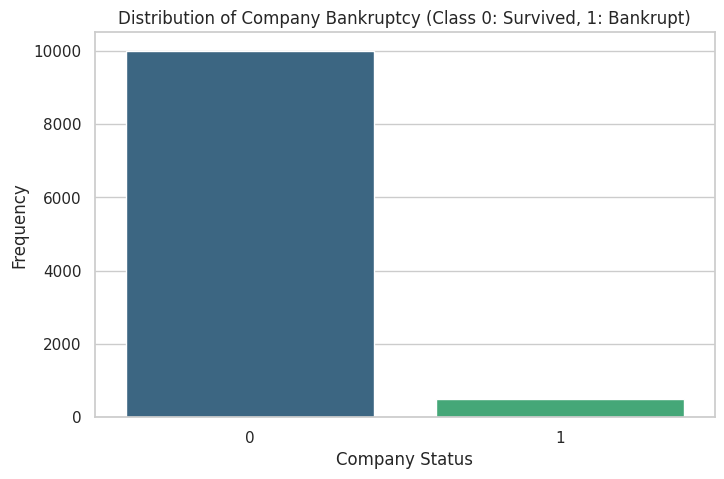

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set the visual style
sns.set_theme(style="whitegrid")

# Plot a bar chart of the class distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='class', data=df, hue='class', palette='viridis', legend=False)
plt.title('Distribution of Company Bankruptcy (Class 0: Survived, 1: Bankrupt)')
plt.xlabel('Company Status')
plt.ylabel('Frequency')
plt.show()


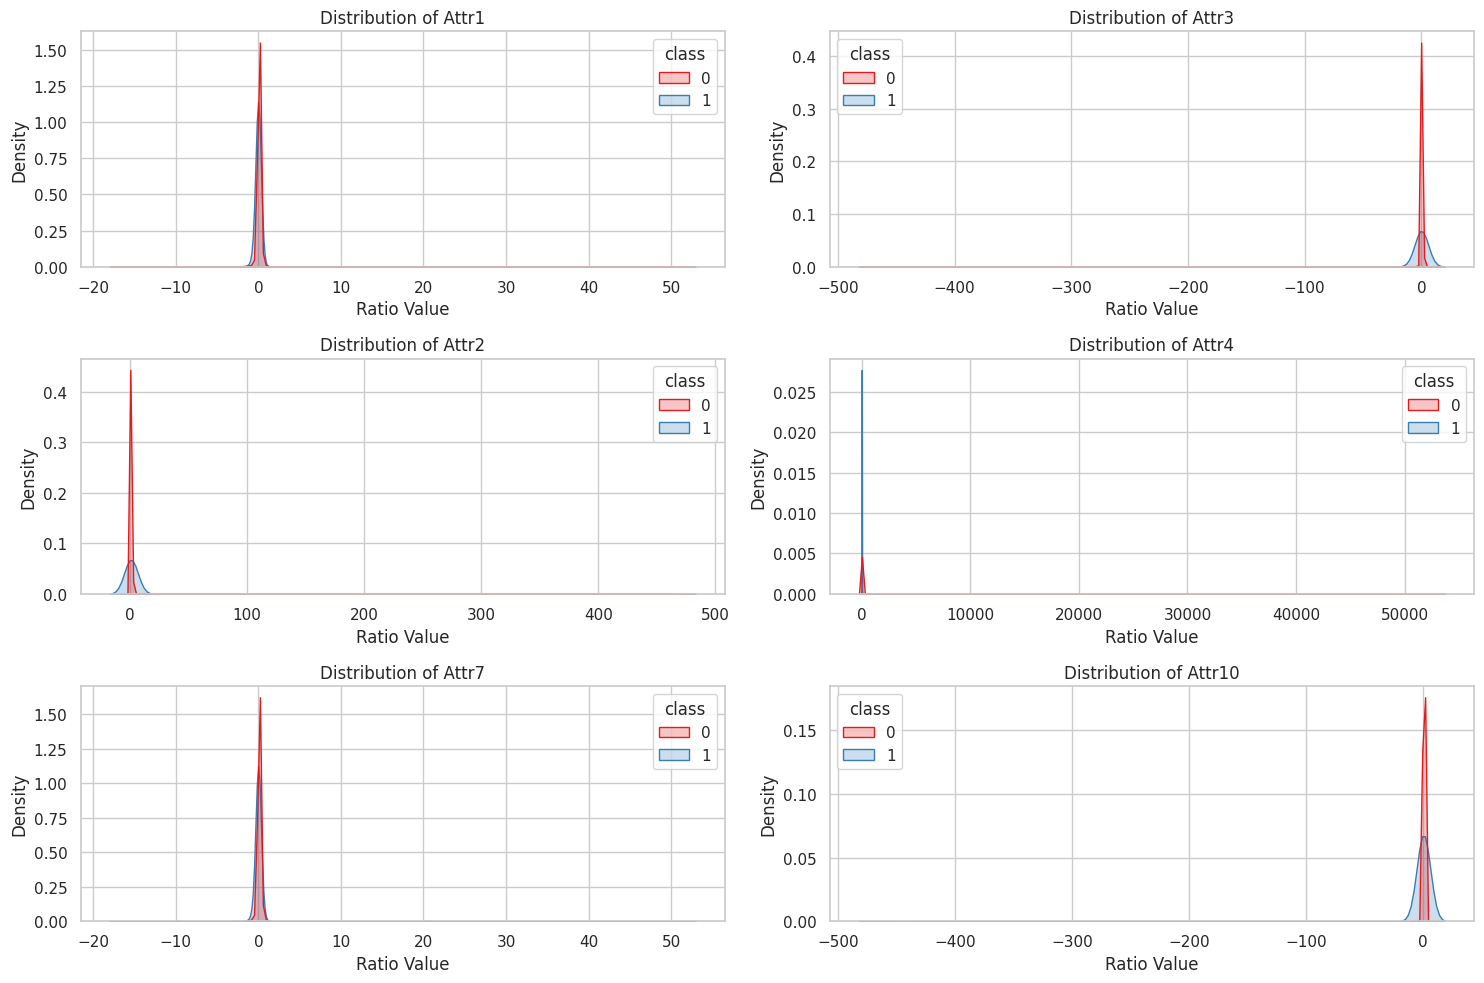

In [ ]:

# Plot histograms or KDE plots for 6 financially meaningful features

# Attr1 (Profitability), Attr3 (Liquidity), Attr2 (Leverage), Attr4 (Short-term Solvency), Attr7 (EBIT/Total Assets), Attr10 (Equity/Total Assets)
features_to_plot = ['Attr1', 'Attr3', 'Attr2', 'Attr4', 'Attr7', 'Attr10']

plt.figure(figsize=(15, 10))
for i, col in enumerate(features_to_plot, 1):
    plt.subplot(3, 2, i)
    # Using KDE plot to visualize density; capping x-axis for better visibility of skewed financial ratios
    sns.kdeplot(data=df, x=col, hue='class', fill=True, common_norm=False, palette='Set1')
    plt.title(f'Distribution of {col}')
    plt.xlabel('Ratio Value')

plt.tight_layout()
plt.show()


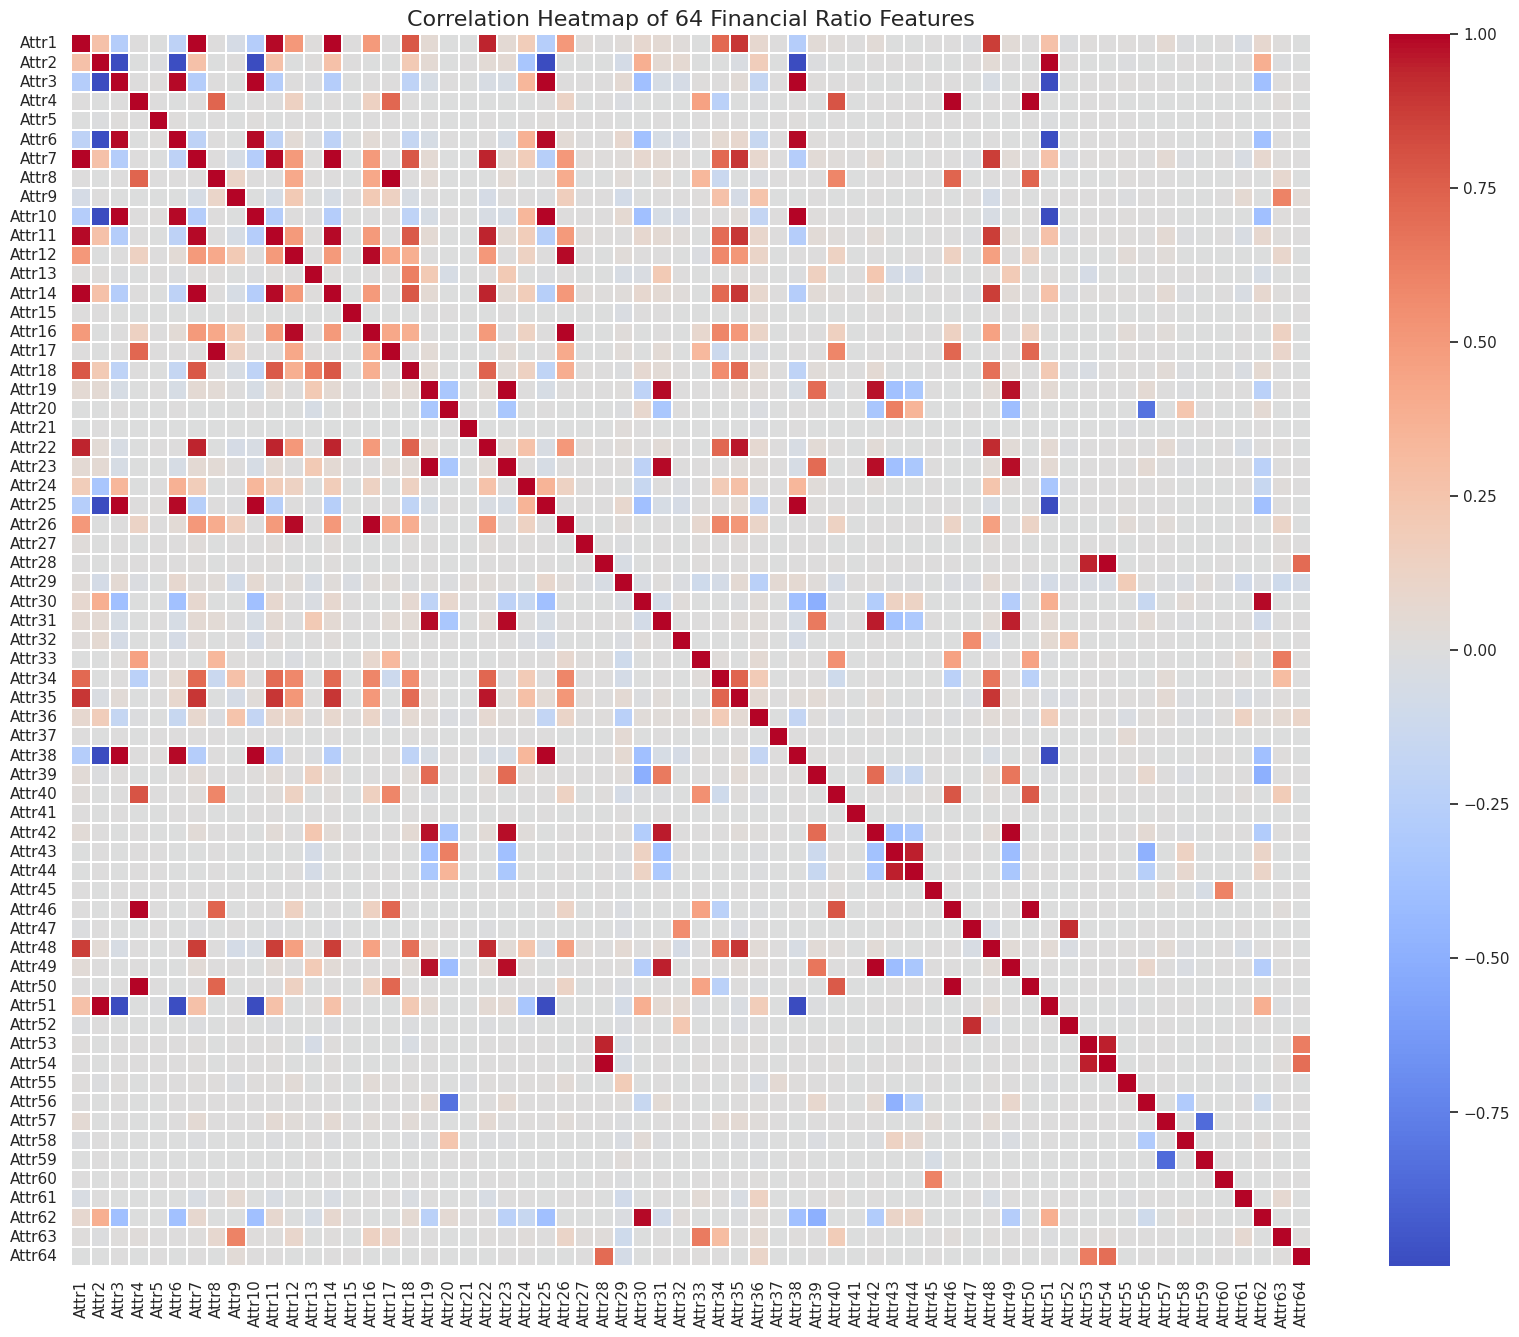

In [ ]:


plt.figure(figsize=(20, 16))
corr_matrix = df.drop('class', axis=1).corr()

# Create the heatmap
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    annot=False,
    linewidths=0.1
)

plt.title('Correlation Heatmap of 64 Financial Ratio Features', fontsize=16)
plt.show()



- Comment on at least two pairs of strongly correlated features:

  - Attr7 (EBIT / total assets) and Attr11 ((gross profit + extraordinary items + financial expenses) / total assets): These features show a near-perfect positive correlation because they both track the core earnings a company generates from its assets. Since the numerator of both ratios effectively measures operating profit before taxes and interest, they move in the same direction whenever a company's profitability changes.

  - Attr2 (total liabilities / total assets) and Attr10 (equity / total assets): These attributes exhibit an extremely strong negative correlation because they represent the two opposite sides of how a company is financed. Because every dollar of assets must be funded by either debt or equity, an increase in the proportion of debt (liabilities) automatically forces the proportion of equity to drop by the same amount.

- Why class imbalance matters for this problem:
  - In this dataset, class imbalance is a significant challenge because only about 4.7% of the companies actually went bankrupt, while the remaining 95.3% survived. If we were to use standard accuracy as our primary metric, a naive model could simply predict that every company will survive and achieve a 95.3% accuracy rate despite failing to identify a single case of insolvency. In the context of credit risk, this would be catastrophic for a lender who needs to identify the rare, high-risk cases rather than the common, healthy ones.

- How it affects the choice of evaluation metric:
  - This imbalance shifts our focus toward metrics like ROC AUC and F1-score, which evaluate how well the model distinguishes between the two classes rather than just looking at the total percentage of correct guesses. Recall becomes particularly vital for this problem because the financial cost of a False Negative indicating missing a bankruptcy is typically much higher than the cost of a False Positive indicating misidentifying a healthy firm. By prioritizing these metrics, we ensure the model is actually learning the subtle financial distress signals hidden within the minority class.

###1d. Train/test split

In [ ]:
from sklearn.model_selection import train_test_split


X = df.drop('class', axis=1)
y = df['class']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size: {X_train.shape}')
print(f'Test size:  {X_test.shape}')


print('\n Class Balance (Percentages)')
print('Train class balance:', y_train.value_counts(normalize=True).round(3).to_dict())
print('Test class balance: ', y_test.value_counts(normalize=True).round(3).to_dict())

Train size: (8402, 64)
Test size:  (2101, 64)

 Class Balance (Percentages)
Train class balance: {0: 0.953, 1: 0.047}
Test class balance:  {0: 0.953, 1: 0.047}


## Phase 2 — Baseline Models

**Introduction:** In this phase, I establish performance benchmarks using traditional algorithms like Logistic Regression and Decision Trees to understand how simpler models handle the bankruptcy prediction task. These baselines provide a critical point of comparison for the more complex ensemble methods developed in the subsequent stages of the project.

### 2a. Decision Tree classifier



Decision Tree Performance Metrics ---
Accuracy:  0.9295573536411232
Precision: 0.27927927927927926
Recall:    0.31313131313131315
F1 Score:  0.29523809523809524
ROC AUC:   0.6365856365856366


<Figure size 800x600 with 0 Axes>

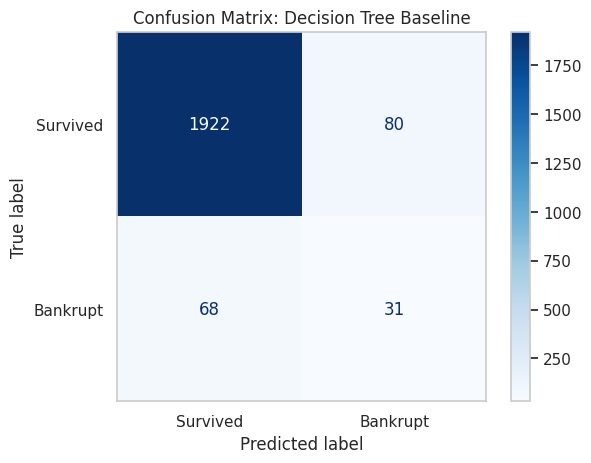

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Instantiate the Decision Tree Classifier with default hyperparameters

dt_model = DecisionTreeClassifier(random_state=42)

# Fit on the training set
dt_model.fit(X_train, y_train)

# Predict on the test set
y_pred_dt = dt_model.predict(X_test)
y_probs_dt = dt_model.predict_proba(X_test)[:, 1]

# Evaluate and print metrics
print("\nDecision Tree Performance Metrics ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_dt)}")
print(f"Precision: {precision_score(y_test, y_pred_dt)}")
print(f"Recall:    {recall_score(y_test, y_pred_dt)}")
print(f"F1 Score:  {f1_score(y_test, y_pred_dt)}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_probs_dt)}")

# Plot a confusion matrix using ConfusionMatrixDisplay
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(
    dt_model, X_test, y_test, cmap='Blues', display_labels=['Survived', 'Bankrupt']
)
plt.title('Confusion Matrix: Decision Tree Baseline')
plt.grid(False) # Clean up the visual
plt.show()

### 2b. Logistic Regression classifier

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression Performance Metrics
Accuracy:  0.9509757258448358
Precision: 0.0
Recall:    0.0
F1 Score:  0.0
ROC AUC:   0.4811652993471175


<Figure size 800x600 with 0 Axes>

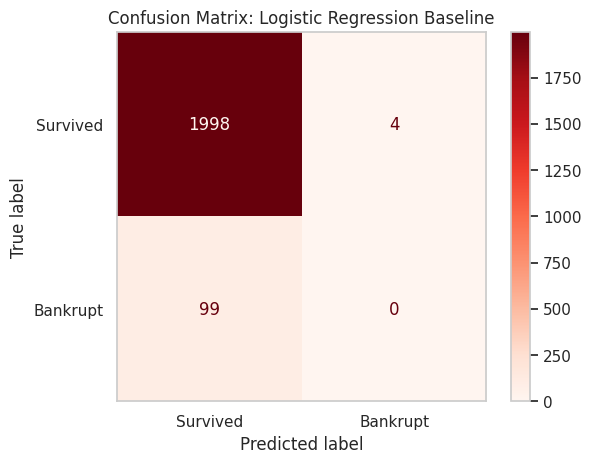

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Instantiate LogisticRegression as a linear baseline
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# Fit on the training set
lr_model.fit(X_train, y_train)

# Predict on the test set
y_pred_lr = lr_model.predict(X_test)
y_probs_lr = lr_model.predict_proba(X_test)[:, 1]

# Evaluate and print the five required metrics
print("\nLogistic Regression Performance Metrics")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr)}")
print(f"Precision: {precision_score(y_test, y_pred_lr)}")
print(f"Recall:    {recall_score(y_test, y_pred_lr)}")
print(f"F1 Score:  {f1_score(y_test, y_pred_lr)}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_probs_lr)}")

# Plot a confusion matrix
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(
    lr_model, X_test, y_test, cmap='Reds', display_labels=['Survived', 'Bankrupt']
)
plt.title('Confusion Matrix: Logistic Regression Baseline')
plt.grid(False)
plt.show()

### **2c. Metric discussion**

- Which metric is most important for predicting bankruptcy, and why?
  - In the context of corporate bankruptcy prediction, Recall and ROC AUC emerge as the most critical metrics because they prioritize the detection of the minority class over simple correct-guessing rates. The financial cost of a false negative which is misclassifying a doomed company as healthy is exceptionally high, as it leads to total capital loss for lenders and investors who fail to initiate early intervention or divestment. On the other hand, a false positive simply results in a missed opportunity or additional auditing costs, which is a far more manageable expense than the catastrophic impact of a loan default.

- What is the cost of a false negative (predicting a company survives when it
will go bankrupt) versus a false positive?
  - In the context of corporate bankruptcy, a false negative is significantly more damaging as it represents a scenario where a lender or investor predicts a company is healthy when it is actually on the verge of collapse. This leads to substantial financial losses, including the total default on principal loans and interest, whereas a false positive merely results in a missed opportunity or Type II error where a potential profit was not realized. Consequently, the operational cost of failing to detect a bankrupt firm is far more than the administrative cost of conducting extra due diligence on a healthy one.

- Why accuracy alone is misleading given the class imbalance in this dataset:
  - Standard accuracy is an unreliable indicator for this dataset because the it is heavily skewed by containing 95% of companies belonging to the survived class. A model could achieve a high accuracy score of 95.3% by simply defaulting to a '0' prediction for every entry, which creates a false sense of security while failing to identify the high-risk firms that are being targeted. This statistical illusion hides the model's inability to learn from the minority class which makes accuracy a poor metric for evaluating true predictive power in bankruptcy prediction.

## Phase 3 — Ensemble Methods

**Introduction:** This phase implements advanced ensemble techniques, such as Random Forest, Gradient Boosting and more, to improve predictive accuracy by combining the strengths of multiple individual models. These methods are specifically chosen for their ability to navigate the non-linear relationships and high-dimensional correlations present in corporate financial statements.

### 3a. Bagging Classifier

In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

# Instantiate the BaggingClassifier
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    oob_score=True,
    random_state=1
)

# Fit on the training set
bagging_model.fit(X_train, y_train)

# Predict on the test set
y_pred_bag = bagging_model.predict(X_test)
y_probs_bag = bagging_model.predict_proba(X_test)[:, 1]

# Evaluate and print metrics
print("\nBagging Classifier Performance Metrics")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_bag)}")
print(f"Precision: {precision_score(y_test, y_pred_bag)}")
print(f"Recall:    {recall_score(y_test, y_pred_bag)}")
print(f"F1 Score:  {f1_score(y_test, y_pred_bag)}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_probs_bag)}")

# Print OOB accuracy vs Test set accuracy
oob_acc = bagging_model.oob_score_
test_acc = accuracy_score(y_test, y_pred_bag)

print(f"\nOOB Accuracy:      {oob_acc}")
print(f"Test Set Accuracy: {test_acc}")


Bagging Classifier Performance Metrics
Accuracy:  0.9590671108995716
Precision: 0.7096774193548387
Recall:    0.2222222222222222
F1 Score:  0.3384615384615385
ROC AUC:   0.8551297187660825

OOB Accuracy:      0.9623899071649608
Test Set Accuracy: 0.9590671108995716


### 3b. Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

# Instantiate the Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    oob_score=True,
    random_state=1
)

# Fit on the training set
rf_model.fit(X_train, y_train)

# Predict on the test set
y_pred_rf = rf_model.predict(X_test)
y_probs_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluate and print metrics
print("\nRandom Forest Performance Metrics ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf)}")
print(f"Precision: {precision_score(y_test, y_pred_rf)}")
print(f"Recall:    {recall_score(y_test, y_pred_rf)}")
print(f"F1 Score:  {f1_score(y_test, y_pred_rf)}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_probs_rf)}")

# Print the OOB score and compare to test performance
oob_score_rf = rf_model.oob_score_
test_acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"\nOOB Score (Accuracy): {oob_score_rf}")
print(f"Test Set Accuracy:    {test_acc_rf}")


Random Forest Performance Metrics ---
Accuracy:  0.9500237981913374
Precision: 0.3125
Recall:    0.050505050505050504
F1 Score:  0.08695652173913043
ROC AUC:   0.8382551791642701

OOB Score (Accuracy): 0.9552487502975482
Test Set Accuracy:    0.9500237981913374


### 3c. AdaBoost Classifier

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

# Instantiate the AdaBoostClassifier
base_dt = DecisionTreeClassifier(max_depth=2, random_state=1)
ada_model = AdaBoostClassifier(
    estimator=base_dt,
    n_estimators=200,
    random_state=1
)

# Fit on the training set
ada_model.fit(X_train, y_train)

# Predict and get class probabilities
y_pred_ada = ada_model.predict(X_test)
y_probs_ada = ada_model.predict_proba(X_test)[:, 1]

# Evaluate using all five metrics
print("\nAdaBoost Performance Metrics ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_ada)}")
print(f"Precision: {precision_score(y_test, y_pred_ada)}")
print(f"Recall:    {recall_score(y_test, y_pred_ada)}")
print(f"F1 Score:  {f1_score(y_test, y_pred_ada)}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_probs_ada)}")


AdaBoost Performance Metrics ---
Accuracy:  0.9590671108995716
Precision: 0.6585365853658537
Recall:    0.2727272727272727
F1 Score:  0.38571428571428573
ROC AUC:   0.8938586665859393


### 3d. Gradient Boosting Classifier


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

# Instantiate the GradientBoostingClassifier
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=4,
    random_state=1
)

# Fit on the training set
gb_model.fit(X_train, y_train)

# Predict on the test set
y_pred_gb = gb_model.predict(X_test)
y_probs_gb = gb_model.predict_proba(X_test)[:, 1]

# Evaluate using the five required metrics
print("\nGradient Boosting Performance Metrics ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_gb)}")
print(f"Precision: {precision_score(y_test, y_pred_gb)}")
print(f"Recall:    {recall_score(y_test, y_pred_gb)}")
print(f"F1 Score:  {f1_score(y_test, y_pred_gb)}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_probs_gb)}")


Gradient Boosting Performance Metrics ---
Accuracy:  0.9638267491670633
Precision: 0.7555555555555555
Recall:    0.3434343434343434
F1 Score:  0.4722222222222222
ROC AUC:   0.909449136721864


### 3e. Model comparison


Model Performance Comparison


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Model,,,,,
Decision Tree Classifier,0.9296,0.2793,0.3131,0.2952,0.6366
Logistic Regression Classifier,0.9510,0.0000,0.0000,0.0000,0.4812
Bagging Classifier,0.9591,0.7097,0.2222,0.3385,0.8551
Random Forest Classifier,0.9500,0.3125,0.0505,0.0870,0.8383
AdaBoost Classifier,0.9591,0.6585,0.2727,0.3857,0.8939
Gradient Boosting Classifier,0.9638,0.7556,0.3434,0.4722,0.9094


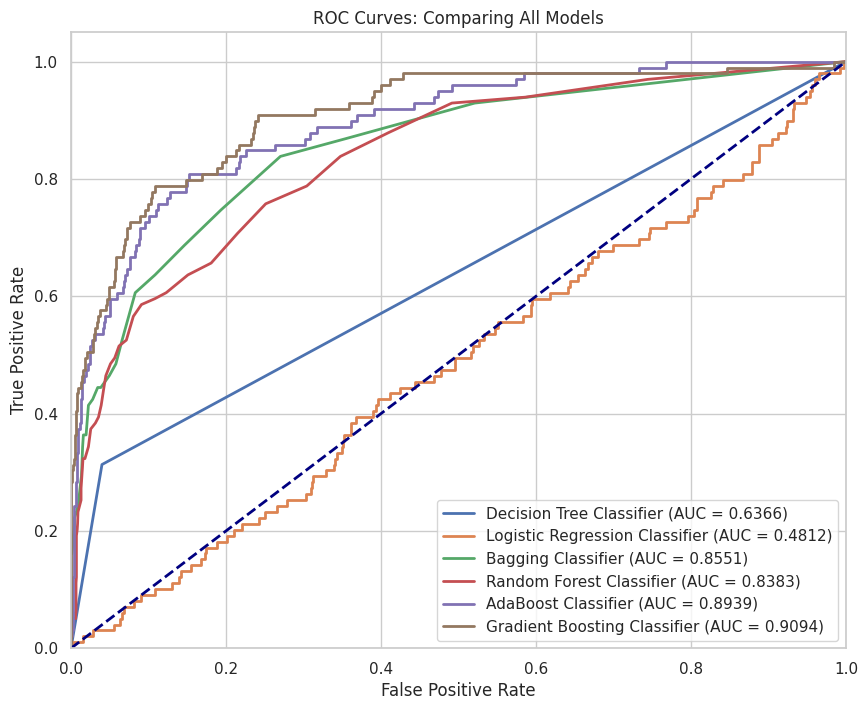

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Create a dictionary to store all metrics for the comparison table

comparison_data = {
    "Model": ["Decision Tree Classifier", "Logistic Regression Classifier", "Bagging Classifier", "Random Forest Classifier",
              "AdaBoost Classifier", "Gradient Boosting Classifier"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_dt), accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_bag), accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_ada), accuracy_score(y_test, y_pred_gb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_dt), precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_bag), precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_ada), precision_score(y_test, y_pred_gb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_dt), recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_bag), recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_ada), recall_score(y_test, y_pred_gb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_dt), f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_bag), f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_ada), f1_score(y_test, y_pred_gb)
    ],
    "ROC AUC": [
        roc_auc_score(y_test, y_probs_dt), roc_auc_score(y_test, y_probs_lr),
        roc_auc_score(y_test, y_probs_bag), roc_auc_score(y_test, y_probs_rf),
        roc_auc_score(y_test, y_probs_ada), roc_auc_score(y_test, y_probs_gb)
    ]
}

# Display the summary DataFrame
results_df = pd.DataFrame(comparison_data).set_index("Model")
print("\nModel Performance Comparison")
display(results_df.round(4))

# Plot ROC curves for all models on the same axes
plt.figure(figsize=(10, 8))

# Define model names and their corresponding probability predictions
models = {
    "Decision Tree Classifier": y_probs_dt,
    "Logistic Regression Classifier": y_probs_lr,
    "Bagging Classifier": y_probs_bag,
    "Random Forest Classifier": y_probs_rf,
    "AdaBoost Classifier": y_probs_ada,
    "Gradient Boosting Classifier": y_probs_gb
}

for name, probs in models.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

# Add plot aesthetics
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Diagonal random line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: Comparing All Models')
plt.legend(loc="lower right")
plt.show()

### 3f. Bias-variance discussion

- **Bias-Variance trade-off discussion:**
  - **The Decision Tree and High Variance:** The Decision Tree Classifier shows the classic behavior of a high-variance model. By achieving a significantly lower ROC AUC of 0.6366 compared to the advanced ensembles, it is clear that the tree is likely overfitting the training data and struggling to generalize to the underlying patterns of the test set. While its Recall (0.3131) is higher than some baselines, the relatively low Precision (0.2793) suggests that the model is capturing noise and making erratic predictions which is like a direct result of a non-linear model that is too sensitive to small fluctuations in the financial data.
  - **Logistic Regression and High Bias:** on the contrary, Logistic Regression Classifier represents a case of high bias, as shown by its ROC AUC of 0.4812, which is actually worse than random guessing. With a Recall and Precision of 0.0000, the model is underfitting the dataset entirely, because it is too simple to capture the complex, non-linear interactions between the 64 financial ratios. Its high Accuracy (0.9510) is deceptive and only a byproduct of the class imbalance which is hiding the fact that the model’s biased linear assumptions prevent it from identifying a single bankrupt company.



## Phase 4 — Hyperparameter Tuning and Interpretation

**Introduction:** The final phase involves refining the top-performing model through automated grid searches to achieve the highest possible diagnostic power for bankruptcy detection.

### 4a. Select and tune the best model

In [ ]:
from sklearn.model_selection import GridSearchCV

params = {
'n_estimators': [150, 200, 250],
'max_depth': [4, 6, 8],
}
grid_search = GridSearchCV(
estimator = gb_model,
param_grid=params,
scoring='roc_auc',
cv=5,
n_jobs=-1,
verbose=1
)
grid_search.fit(X_train, y_train)
print('Best parameters:', grid_search.best_params_)
print('Best CV AUC: ', round(grid_search.best_score_, 4))

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best parameters: {'max_depth': 6, 'n_estimators': 250}
Best CV AUC:  0.917


In [ ]:
# Extract results and the tuned model
best_params = grid_search.best_params_
tuned_auc = grid_search.best_score_
untuned_auc = roc_auc_score(y_test, y_probs_gb)
improvement = tuned_auc - untuned_auc


print("\nHyperparameter Tuning Results")
print(f"Best Parameters: {best_params}")
print(f"Untuned ROC AUC: {untuned_auc}")
print(f"Tuned CV ROC AUC: {tuned_auc}")
print(f"Improvement:     {improvement}")


Hyperparameter Tuning Results
Best Parameters: {'max_depth': 6, 'n_estimators': 250}
Untuned ROC AUC: 0.909449136721864
Tuned CV ROC AUC: 0.9170081195548947
Improvement:     0.007558982833030692


In [ ]:
# Convert cv_results_ to a pandas DataFrame
cv_results_df = pd.DataFrame(grid_search.cv_results_)

# Display the top 5 combinations by rank
print("\nTop 5 Parameter Combinations")
display(cv_results_df[['params', 'mean_test_score', 'rank_test_score']].sort_values('rank_test_score').head(5))


Top 5 Parameter Combinations


,params,mean_test_score,rank_test_score
5,"{'max_depth': 6, 'n_estimators': 250}",0.917008,1
2,"{'max_depth': 4, 'n_estimators': 250}",0.916627,2
1,"{'max_depth': 4, 'n_estimators': 200}",0.916125,3
4,"{'max_depth': 6, 'n_estimators': 200}",0.915620,4
0,"{'max_depth': 4, 'n_estimators': 150}",0.913131,5


### 4b. Feature importance analysis

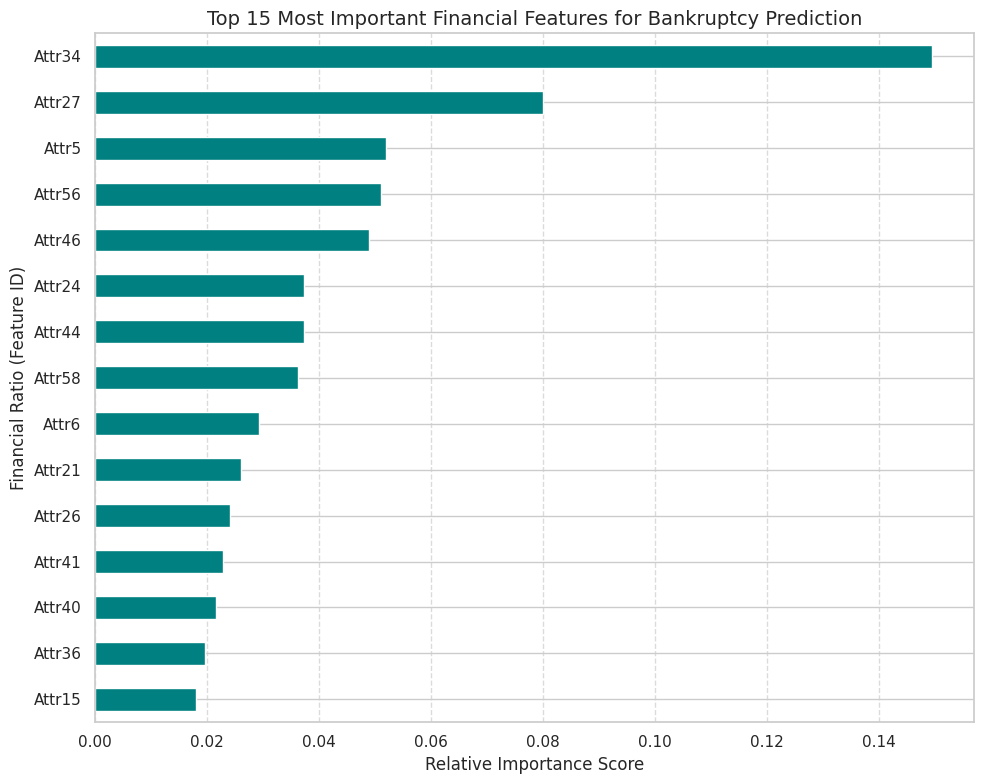


------------Top 5 Features for Business Interpretation------------
Attr34    0.149539
Attr27    0.079978
Attr5     0.052051
Attr56    0.051110
Attr46    0.048995
dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Extract feature importances from the tuned model
tuned_model = grid_search.best_estimator_
importances = tuned_model.feature_importances_
feature_names = X.columns

# Create a series for easy sorting and plotting
feat_importances = pd.Series(importances, index=feature_names)

# Sort and select the top 15 most important features
top_15_features = feat_importances.sort_values(ascending=True).tail(15)

# Plot a horizontal bar chart
plt.figure(figsize=(10, 8))
top_15_features.plot(kind='barh', color='teal')

# Label axes and include a chart title
plt.title('Top 15 Most Important Financial Features for Bankruptcy Prediction', fontsize=14)
plt.xlabel('Relative Importance Score')
plt.ylabel('Financial Ratio (Feature ID)')

# Add gridlines for better readability
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


print("\n------------Top 5 Features for Business Interpretation------------")
print(top_15_features.sort_values(ascending=False).head(5))

### 4c. Business interpretation

- **Attr34 (Operating Expenses / Total Liabilities):** This ratio measures a company’s operational efficiency relative to its total debt obligations. A high value is often a warning sign of financial distress, suggesting that operating costs are disproportionately high compared to the firm's leverage, which can quickly drain cash reserves. Conversely, a low value indicates that the company is managing its overhead effectively relative to its size and debt, similar to the efficiency concepts explored in the DuPont Analysis to measure how well a firm controls its costs.

- **Attr27 (Profit on Operating Activities / Financial Expenses):** Commonly known as the Interest Coverage Ratio. This feature is a critical indicator of solvency. A high value signals robust financial health, showing the company generates ample profit to cover its interest payments several times over. A low value, especially one approaching or falling below 1.0 indicates that the company is struggling to meet its debt service requirements, which is a primary red flag used in the Altman Z-score to predict impending default.

- **Attr5 (Cash + Securities + Receivables - Short-term Liabilities) / (Operating Expenses - Depreciation)** * **365**: This complex ratio represents the Defensive Interval Ratio in days, measuring how many days a company can operate using only its liquid assets. A high value provides a significant safety net which is signaling that the firm can survive for a long period without immediate new sales or financing. A low value suggests a precarious liquidity position where any delay in revenue could lead to an immediate inability to pay daily operating expenses.

- **Attr56 (Sales - Cost of Products Sold) / Sales:** This is the Gross Profit Margin, a fundamental measure of pricing power and production efficiency. A high value indicates that the company maintains a strong competitive advantage and can comfortably cover its operating expenses with the remaining revenue. A low or shrinking value suggests that rising production costs or competitive pricing pressure are squeezing the company and often serving as an early-stage indicator of long-term insolvency.

- **Attr46 (Current Assets - Inventory) / Short-term Liabilities:** It is known the Quick Ratio or Acid-Test. This measures a company’s ability to meet short-term obligations without relying on the sale of inventory. A high value (typically above 1.0) signals strong immediate liquidity and the ability to pay off debts instantly using only highly liquid assets. A low value indicates that the company is overly dependent on selling its stock to remain solvent, which is dangerous if market demand shifts or inventory becomes obsolete.

# Executive Summary

Following an extensive evaluation of several risk assessment models, I recommend the adoption of the Gradient Boosting Classifier for the bankruptcy prediction pipeline. This model achieved the highest performance during testing, specifically attaining a 91.7% ROC AUC score. This metric indicates that the model has a high degree of reliability in distinguishing between stable companies and those at risk of failure, significantly outperforming traditional linear assessment methods.

My analysis identified several key risk indicators that serve as the primary predictors of financial instability. The most critical signals include a company’s ability to cover interest payments from profits, its overall operational efficiency, and its immediate liquidity (the ability to cover debts without relying on inventory sales). Monitoring these specific ratios will provide earlier warnings than standard balance sheet reviews.

It is important to note that because actual bankruptcy is a relatively rare event, the model is designed to be conservative. I have prioritized catching as many potential defaults as possible, acknowledging that this may result in some false alarms that require manual review. Given that the cost of a missed default is significantly higher than the cost of additional auditing, this model provides a robust first line of defense for credit portfolio.

Gradient Boosting Classifier is recommended as the risk assessment tool, as it achieved a superior ROC AUC of 91.7% by following hyperparameter tuning. This model effectively identifies high-risk firms by tracking key predictive signals such as the Operating Efficiency, Interest Coverage Ratio, and Quick Liquidity, which provide much earlier warnings of distress than traditional manual reviews. While the model is highly effective, it is important to note that an optimization has been done to prioritize Recall to address the high cost of false negatives instances (indicating where a bankruptcy is missed), ensuring that the rare but catastrophic event of a loan default will be captured even at the expense of occasional additional auditing for healthy firms.